# Ablation — NF4 Quantization

This notebook analyzes the W&B runs for the NF4 follow-up experiment.

The expected NF4 sweep is:

| Factor | Values |
|---|---|
| Method | `NF4` |
| Granularity | `per_tensor`, `per_channel` |
| Calibration | `uncalibrated`, `percentile` for per-channel; `uncalibrated` for per-tensor |
| Seeds | `1337`, `42`, `123` |

Expected NF4 runs: **3 configurations × 3 seeds = 9 runs**.

The goal is to compare NF4 against the best uniform INT4 baseline from the previous quantization design study:

`quant_design_4_per_channel_symmetric_uncalibrated_seed{seed}`

Main metric: **final validation BPB after quantize → compress → reload/dequantize → evaluate**.


## Setup

In [ ]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb

# Optional project styling, compatible with previous notebooks.
try:
    import importlib, utils
    importlib.reload(utils)
    from utils import apply_style, get_deep_palette
    apply_style(force=True)
    PALETTE = get_deep_palette()
except Exception:
    plt.rcParams.update({
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    })
    PALETTE = [
        "#4C78A8", "#F58518", "#54A24B", "#E45756",
        "#72B7B2", "#B279A2", "#FF9DA6", "#9D755D",
    ]

ENTITY = "the-golfers"
PROJECT = "ml_ai_project"
api = wandb.Api()

SEED_ORDER = [1337, 42, 123]
NF4_CONFIGS = [
    ("per_tensor", "uncalibrated"),
    ("per_channel", "uncalibrated"),
    ("per_channel", "percentile"),
]

DISPLAY_LABELS = {
    "per_tensor": "per-tensor",
    "per_channel": "per-channel",
    "uncalibrated": "uncalibrated",
    "percentile": "percentile-clipped",
    "nf4": "NF4",
    "uniform_int4": "Uniform INT4",
}

OUT_DIR = Path("../notebook_outputs/nf4_ablation")
OUT_DIR.mkdir(parents=True, exist_ok=True)

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\fmene\_netrc.


## Download NF4 and baseline runs from W&B

This cell uses the W&B API and saves a raw CSV similar to the export snippet from W&B.

It filters:

- NF4 runs matching `nf4_<granularity>_<calibration>_seed<seed>`
- Best INT4 baseline runs matching `quant_design_4_per_channel_symmetric_uncalibrated_seed<seed>`


In [2]:
NF4_RUN_RE = re.compile(
    r"^nf4_"
    r"(?P<granularity>per_tensor|per_channel)_"
    r"(?P<calibration>uncalibrated|percentile)_"
    r"seed(?P<seed>1337|42|123)$"
)

BASELINE_RUN_RE = re.compile(
    r"^quant_design_4_per_channel_symmetric_uncalibrated_"
    r"seed(?P<seed>1337|42|123)$"
)

expected_nf4_names = {
    f"nf4_{gran}_{cal}_seed{seed}"
    for gran, cal in NF4_CONFIGS
    for seed in SEED_ORDER
}
expected_baseline_names = {
    f"quant_design_4_per_channel_symmetric_uncalibrated_seed{seed}"
    for seed in SEED_ORDER
}

# Regex includes both NF4 runs and the best prior uniform INT4 baseline.
wandb_filter = {
    "display_name": {
        "$regex": (
            r"^(nf4_(per_tensor|per_channel)_(uncalibrated|percentile)_seed(1337|42|123)"
            r"|quant_design_4_per_channel_symmetric_uncalibrated_seed(1337|42|123))$"
        )
    }
}

runs = list(api.runs(f"{ENTITY}/{PROJECT}", filters=wandb_filter))
print(f"Fetched {len(runs)} matching W&B run objects before de-duplication")

summary_list, config_list, name_list, state_list, created_at_list, run_id_list = [], [], [], [], [], []
for run in runs:
    summary_list.append(run.summary._json_dict)
    config_list.append({k: v for k, v in run.config.items() if not k.startswith("_")})
    name_list.append(run.name)
    state_list.append(run.state)
    created_at_list.append(run.created_at)
    run_id_list.append(run.id)

runs_df = pd.DataFrame({
    "summary": summary_list,
    "config": config_list,
    "name": name_list,
    "state": state_list,
    "created_at": created_at_list,
    "run_id": run_id_list,
})

runs_df.to_csv(OUT_DIR / "wandb_raw_nf4_and_int4_runs.csv", index=False)
runs_df.head()

Fetched 12 matching W&B run objects before de-duplication


,summary,config,name,state,created_at,run_id
0,"{'_runtime': 2692, '_step': 5000, '_timestamp'...","{'seed': 1337, 'beta1': 0.9, 'beta2': 0.95, 's...",quant_design_4_per_channel_symmetric_uncalibra...,finished,2026-05-07T23:30:33Z,ueniak4p
1,"{'_runtime': 2688, '_step': 5000, '_timestamp'...","{'seed': 42, 'beta1': 0.9, 'beta2': 0.95, 'see...",quant_design_4_per_channel_symmetric_uncalibra...,finished,2026-05-08T00:16:20Z,ohd4yrec
2,"{'_runtime': 2689, '_step': 5000, '_timestamp'...","{'seed': 123, 'beta1': 0.9, 'beta2': 0.95, 'se...",quant_design_4_per_channel_symmetric_uncalibra...,finished,2026-05-08T01:01:58Z,oiwo29kf
3,"{'_runtime': 2339, '_step': 5000, '_timestamp'...","{'seed': 1337, 'beta1': 0.9, 'beta2': 0.95, 's...",nf4_per_tensor_uncalibrated_seed1337,finished,2026-05-13T07:13:20Z,d28gty4h
4,"{'_runtime': 2275, '_step': 5000, '_timestamp'...","{'seed': 1337, 'beta1': 0.9, 'beta2': 0.95, 's...",nf4_per_channel_uncalibrated_seed1337,finished,2026-05-13T07:53:09Z,9bcrttq6


## Parse run names and extract metrics

The main metric is `final_val_bpb`, which should correspond to the post-roundtrip validation BPB.

The notebook also extracts:

- `final_val_loss`
- `quant_file_bytes`
- `fp32_val_bpb`, when available from history
- `delta_bpb = final_val_bpb - fp32_val_bpb`, when available


In [ ]:
def first_present(mapping, keys, default=np.nan):
    for k in keys:
        if k in mapping and mapping[k] is not None:
            return mapping[k]
    return default

# Keep latest finished run if duplicates exist. If no finished run exists for a name, keep latest run anyway.
runs_sorted = sorted(runs, key=lambda r: str(r.created_at or ""))
latest_by_name = {}
for run in runs_sorted:
    if run.name not in latest_by_name:
        latest_by_name[run.name] = run
    elif run.state == "finished":
        latest_by_name[run.name] = run
    elif latest_by_name[run.name].state != "finished":
        latest_by_name[run.name] = run

selected_runs = list(latest_by_name.values())
print(f"Selected {len(selected_runs)} unique run names after de-duplication")

rows = []
for run in selected_runs:
    nf4_match = NF4_RUN_RE.match(run.name)
    base_match = BASELINE_RUN_RE.match(run.name)
    if not nf4_match and not base_match:
        continue

    s = run.summary._json_dict
    cfg = {k: v for k, v in run.config.items() if not k.startswith("_")}

    # Pre-roundtrip validation BPB, if the training history exists.
    fp32_bpb = np.nan
    try:
        hist = run.history(keys=["_step", "val_bpb"], pandas=True)
        if not hist.empty and "val_bpb" in hist:
            vals = hist["val_bpb"].dropna()
            if len(vals):
                fp32_bpb = float(vals.iloc[-1])
    except Exception as e:
        print(f"Could not fetch history for {run.name}: {e}")

    final_val_bpb = first_present(s, ["final_val_bpb", "val_bpb", "roundtrip_val_bpb"])
    final_val_loss = first_present(s, ["final_val_loss", "val_loss", "roundtrip_val_loss"])
    quant_file_bytes = first_present(s, ["quant_file_bytes", "compressed_model_bytes", "model_int8_bytes"])

    if nf4_match:
        info = nf4_match.groupdict()
        rows.append({
            "run_name": run.name,
            "run_id": run.id,
            "state": run.state,
            "created_at": run.created_at,
            "method": "nf4",
            "bits": 4,
            "granularity": info["granularity"],
            "symmetry": "codebook",
            "calibration": info["calibration"],
            "seed": int(info["seed"]),
            "fp32_val_bpb": fp32_bpb,
            "final_val_bpb": final_val_bpb,
            "final_val_loss": final_val_loss,
            "quant_file_bytes": quant_file_bytes,
            "quant_file_MB": quant_file_bytes / 1e6 if pd.notna(quant_file_bytes) else np.nan,
            "quant_method_cfg": cfg.get("quant_method", cfg.get("QUANT_METHOD", np.nan)),
            "quant_granularity_cfg": cfg.get("quant_granularity", cfg.get("QUANT_GRANULARITY", np.nan)),
            "quant_calibration_cfg": cfg.get("quant_calibration", cfg.get("QUANT_CALIBRATION", np.nan)),
        })
    else:
        seed = int(base_match.groupdict()["seed"])
        rows.append({
            "run_name": run.name,
            "run_id": run.id,
            "state": run.state,
            "created_at": run.created_at,
            "method": "uniform_int4",
            "bits": 4,
            "granularity": "per_channel",
            "symmetry": "symmetric",
            "calibration": "uncalibrated",
            "seed": seed,
            "fp32_val_bpb": fp32_bpb,
            "final_val_bpb": final_val_bpb,
            "final_val_loss": final_val_loss,
            "quant_file_bytes": quant_file_bytes,
            "quant_file_MB": quant_file_bytes / 1e6 if pd.notna(quant_file_bytes) else np.nan,
            "quant_method_cfg": "uniform_int4_baseline",
            "quant_granularity_cfg": "per_channel",
            "quant_calibration_cfg": "uncalibrated",
        })

df = pd.DataFrame(rows)

# Ordering helpers.
method_order = {"uniform_int4": 0, "nf4": 1}
gran_order = {"per_tensor": 0, "per_channel": 1}
cal_order = {"uncalibrated": 0, "percentile": 1}
df["method_order"] = df["method"].map(method_order)
df["gran_order"] = df["granularity"].map(gran_order)
df["cal_order"] = df["calibration"].map(cal_order)
df = df.sort_values(["method_order", "gran_order", "cal_order", "seed"]).reset_index(drop=True)

# Quantization damage, when fp32 history is available.
df["delta_bpb"] = df["final_val_bpb"] - df["fp32_val_bpb"]

found_nf4_names = set(df[df["method"] == "nf4"]["run_name"])
found_baseline_names = set(df[df["method"] == "uniform_int4"]["run_name"])
missing_nf4 = sorted(expected_nf4_names - found_nf4_names)
missing_baseline = sorted(expected_baseline_names - found_baseline_names)
extra_nf4 = sorted(found_nf4_names - expected_nf4_names)

print(f"Rows in parsed dataframe: {len(df)}")
print(f"Missing expected NF4 names: {len(missing_nf4)}")
if missing_nf4:
    print("\n".join(missing_nf4))
print(f"Missing expected baseline names: {len(missing_baseline)}")
if missing_baseline:
    print("\n".join(missing_baseline))
print(f"Extra NF4 names: {len(extra_nf4)}")
if extra_nf4:
    print("\n".join(extra_nf4))

bad_state = df[df["state"] != "finished"]
if not bad_state.empty:
    print("\nWarning: these selected runs are not marked finished:")
    print(bad_state[["run_name", "state", "created_at"]].to_string(index=False))

df.to_csv(OUT_DIR / "nf4_raw_runs.csv", index=False)
df.head(12)

Selected 12 unique run names after de-duplication
Rows in parsed dataframe: 12
Missing expected NF4 names: 0
Missing expected baseline names: 0
Extra NF4 names: 0


,run_name,run_id,state,created_at,method,bits,granularity,symmetry,calibration,seed,...,final_val_loss,quant_file_bytes,quant_file_MB,quant_method_cfg,quant_granularity_cfg,quant_calibration_cfg,method_order,gran_order,cal_order,delta_bpb
0,quant_design_4_per_channel_symmetric_uncalibra...,ohd4yrec,finished,2026-05-08T00:16:20Z,uniform_int4,4,per_channel,symmetric,uncalibrated,42,...,4.339609,7814961,7.814961,uniform_int4_baseline,per_channel,uncalibrated,0,1,0,1.262247
1,quant_design_4_per_channel_symmetric_uncalibra...,oiwo29kf,finished,2026-05-08T01:01:58Z,uniform_int4,4,per_channel,symmetric,uncalibrated,123,...,4.296561,7823574,7.823574,uniform_int4_baseline,per_channel,uncalibrated,0,1,0,1.239532
2,quant_design_4_per_channel_symmetric_uncalibra...,ueniak4p,finished,2026-05-07T23:30:33Z,uniform_int4,4,per_channel,symmetric,uncalibrated,1337,...,4.406451,7813333,7.813333,uniform_int4_baseline,per_channel,uncalibrated,0,1,0,1.303009
3,nf4_per_tensor_uncalibrated_seed42,slq6a968,finished,2026-05-13T09:10:29Z,nf4,4,per_tensor,codebook,uncalibrated,42,...,8.219371,6463408,6.463408,nf4,per_tensor,uncalibrated,1,0,0,3.560740
4,nf4_per_tensor_uncalibrated_seed123,1x9juuyh,finished,2026-05-13T11:06:14Z,nf4,4,per_tensor,codebook,uncalibrated,123,...,16.731305,6409391,6.409391,nf4,per_tensor,uncalibrated,1,0,0,8.603928
5,nf4_per_tensor_uncalibrated_seed1337,d28gty4h,finished,2026-05-13T07:13:20Z,nf4,4,per_tensor,codebook,uncalibrated,1337,...,13.159941,6543376,6.543376,nf4,per_tensor,uncalibrated,1,0,0,6.487979
6,nf4_per_channel_uncalibrated_seed42,k60w07gr,finished,2026-05-13T09:49:05Z,nf4,4,per_channel,codebook,uncalibrated,42,...,3.098250,7905366,7.905366,nf4,per_channel,uncalibrated,1,1,0,0.527493
7,nf4_per_channel_uncalibrated_seed123,m6qg0bbr,finished,2026-05-13T11:44:42Z,nf4,4,per_channel,codebook,uncalibrated,123,...,3.025215,7905096,7.905096,nf4,per_channel,uncalibrated,1,1,0,0.486324
8,nf4_per_channel_uncalibrated_seed1337,9bcrttq6,finished,2026-05-13T07:53:09Z,nf4,4,per_channel,codebook,uncalibrated,1337,...,3.076700,7905041,7.905041,nf4,per_channel,uncalibrated,1,1,0,0.516199
9,nf4_per_channel_percentile_seed42,he1pnqjm,finished,2026-05-13T10:27:41Z,nf4,4,per_channel,codebook,percentile,42,...,3.113728,7906371,7.906371,nf4,per_channel,percentile,1,1,1,0.537042


## Sanity checks

NF4 should have 3 seeds per configuration. The baseline should also have 3 seeds.


In [ ]:
count_table = (
    df.groupby(["method", "granularity", "symmetry", "calibration"])
      .size()
      .reset_index(name="n_seeds")
      .sort_values(["method", "granularity", "symmetry", "calibration"])
)
print(count_table.to_string(index=False))

nf4_counts_ok = (
    len(df[df["method"] == "nf4"]) == 9
    and (count_table[count_table["method"] == "nf4"]["n_seeds"] == 3).all()
)
baseline_counts_ok = (
    len(df[df["method"] == "uniform_int4"]) == 3
    and (count_table[count_table["method"] == "uniform_int4"]["n_seeds"] == 3).all()
)

if nf4_counts_ok:
    print("\nOK: all expected NF4 runs are present with 3 seeds per configuration.")
else:
    print("\nWARNING: expected 9 NF4 runs and 3 seeds per NF4 configuration.")

if baseline_counts_ok:
    print("OK: best INT4 baseline is present with 3 seeds.")
else:
    print("WARNING: expected 3 best INT4 baseline runs.")

      method granularity  symmetry  calibration  n_seeds
         nf4 per_channel  codebook   percentile        3
         nf4 per_channel  codebook uncalibrated        3
         nf4  per_tensor  codebook uncalibrated        3
uniform_int4 per_channel symmetric uncalibrated        3

OK: all expected NF4 runs are present with 3 seeds per configuration.
OK: best INT4 baseline is present with 3 seeds.


## Aggregate over seeds

This table is the main result: one row per quantization configuration.


In [ ]:
agg = (
    df.groupby(["method", "bits", "granularity", "symmetry", "calibration"], as_index=False)
      .agg(
          n_seeds=("seed", "count"),
          final_val_bpb_mean=("final_val_bpb", "mean"),
          final_val_bpb_std=("final_val_bpb", "std"),
          final_val_loss_mean=("final_val_loss", "mean"),
          final_val_loss_std=("final_val_loss", "std"),
          fp32_val_bpb_mean=("fp32_val_bpb", "mean"),
          delta_bpb_mean=("delta_bpb", "mean"),
          delta_bpb_std=("delta_bpb", "std"),
          quant_file_MB_mean=("quant_file_MB", "mean"),
          quant_file_MB_std=("quant_file_MB", "std"),
      )
)

agg["method_order"] = agg["method"].map(method_order)
agg["gran_order"] = agg["granularity"].map(gran_order)
agg["cal_order"] = agg["calibration"].map(cal_order)
agg = agg.sort_values(["method_order", "gran_order", "cal_order"]).reset_index(drop=True)
agg = agg.drop(columns=["method_order", "gran_order", "cal_order"])

agg["config"] = (
    agg["method"].map(DISPLAY_LABELS) + " / " +
    agg["granularity"].map(DISPLAY_LABELS) + " / " +
    agg["symmetry"] + " / " +
    agg["calibration"].map(DISPLAY_LABELS)
)

agg.to_csv(OUT_DIR / "nf4_aggregated_by_config.csv", index=False)

cols = [
    "config", "n_seeds",
    "final_val_bpb_mean", "final_val_bpb_std",
    "delta_bpb_mean", "delta_bpb_std",
    "quant_file_MB_mean", "quant_file_MB_std",
]
agg[cols]

,config,n_seeds,final_val_bpb_mean,final_val_bpb_std,delta_bpb_mean,delta_bpb_std,quant_file_MB_mean,quant_file_MB_std
0,Uniform INT4 / per-channel / symmetric / uncal...,3,2.574858,0.032795,1.268263,0.032163,7.817289,0.005503
1,NF4 / per-tensor / codebook / uncalibrated,3,7.523751,2.531470,6.217549,2.532446,6.472058,0.067410
2,NF4 / per-channel / codebook / uncalibrated,3,1.816285,0.022225,0.510005,0.021272,7.905168,0.000174
3,NF4 / per-channel / codebook / percentile-clipped,3,1.821069,0.020774,0.514850,0.020153,7.906670,0.001605


## Best configurations

Lower `final_val_bpb_mean` is better.


In [ ]:
best = agg.sort_values("final_val_bpb_mean").reset_index(drop=True)
show = best[[
    "method", "bits", "granularity", "symmetry", "calibration", "n_seeds",
    "final_val_bpb_mean", "final_val_bpb_std",
    "delta_bpb_mean", "quant_file_MB_mean",
]].copy()

for c in ["final_val_bpb_mean", "final_val_bpb_std", "delta_bpb_mean", "quant_file_MB_mean"]:
    show[c] = show[c].map(lambda x: f"{x:.6f}" if pd.notna(x) else "—")
show

,method,bits,granularity,symmetry,calibration,n_seeds,final_val_bpb_mean,final_val_bpb_std,delta_bpb_mean,quant_file_MB_mean
0,nf4,4,per_channel,codebook,uncalibrated,3,1.816285,0.022225,0.510005,7.905168
1,nf4,4,per_channel,codebook,percentile,3,1.821069,0.020774,0.514850,7.906670
2,uniform_int4,4,per_channel,symmetric,uncalibrated,3,2.574858,0.032795,1.268263,7.817289
3,nf4,4,per_tensor,codebook,uncalibrated,3,7.523751,2.531470,6.217549,6.472058


## NF4 vs best uniform INT4 baseline

The baseline is your previous best INT4 configuration:

`4-bit / per-channel / symmetric / uncalibrated`

This section computes NF4 deltas relative to that baseline. Negative means NF4 is better.


In [ ]:
baseline_row = agg[agg["method"] == "uniform_int4"].copy()
if baseline_row.empty:
    print("Baseline row not found. Check that the previous quant_design runs are in W&B.")
else:
    baseline_bpb = float(baseline_row["final_val_bpb_mean"].iloc[0])
    baseline_size = float(baseline_row["quant_file_MB_mean"].iloc[0])
    nf4_vs = agg[agg["method"] == "nf4"].copy()
    nf4_vs["bpb_minus_uniform_int4"] = nf4_vs["final_val_bpb_mean"] - baseline_bpb
    nf4_vs["size_MB_minus_uniform_int4"] = nf4_vs["quant_file_MB_mean"] - baseline_size
    nf4_vs = nf4_vs.sort_values("final_val_bpb_mean")
    display(nf4_vs[[
        "granularity", "calibration", "n_seeds",
        "final_val_bpb_mean", "final_val_bpb_std", "bpb_minus_uniform_int4",
        "quant_file_MB_mean", "size_MB_minus_uniform_int4",
    ]])
    nf4_vs.to_csv(OUT_DIR / "nf4_vs_best_uniform_int4.csv", index=False)

,granularity,calibration,n_seeds,final_val_bpb_mean,final_val_bpb_std,bpb_minus_uniform_int4,quant_file_MB_mean,size_MB_minus_uniform_int4
2,per_channel,uncalibrated,3,1.816285,0.022225,-0.758573,7.905168,0.087878
3,per_channel,percentile,3,1.821069,0.020774,-0.753789,7.906670,0.089381
1,per_tensor,uncalibrated,3,7.523751,2.531470,4.948893,6.472058,-1.345231


## Pivot table

In [ ]:
nf4_only = agg[agg["method"] == "nf4"].copy()

pivot_bpb = nf4_only.pivot_table(
    index="granularity",
    columns="calibration",
    values="final_val_bpb_mean",
).reindex(index=["per_tensor", "per_channel"], columns=["uncalibrated", "percentile"])

pivot_size = nf4_only.pivot_table(
    index="granularity",
    columns="calibration",
    values="quant_file_MB_mean",
).reindex(index=["per_tensor", "per_channel"], columns=["uncalibrated", "percentile"])

print("NF4: mean final_val_bpb")
display(pivot_bpb)
print("\nNF4: mean compressed file size (MB)")
display(pivot_size)

pivot_bpb.to_csv(OUT_DIR / "nf4_pivot_bpb.csv")
pivot_size.to_csv(OUT_DIR / "nf4_pivot_size.csv")

NF4: mean final_val_bpb


calibration,uncalibrated,percentile
granularity,,
per_tensor,7.523751,NaN
per_channel,1.816285,1.821069



NF4: mean compressed file size (MB)


calibration,uncalibrated,percentile
granularity,,
per_tensor,6.472058,NaN
per_channel,7.905168,7.90667


## Plot: final BPB by configuration

Each bar is the average over 3 seeds. Error bars show one standard deviation across seeds.


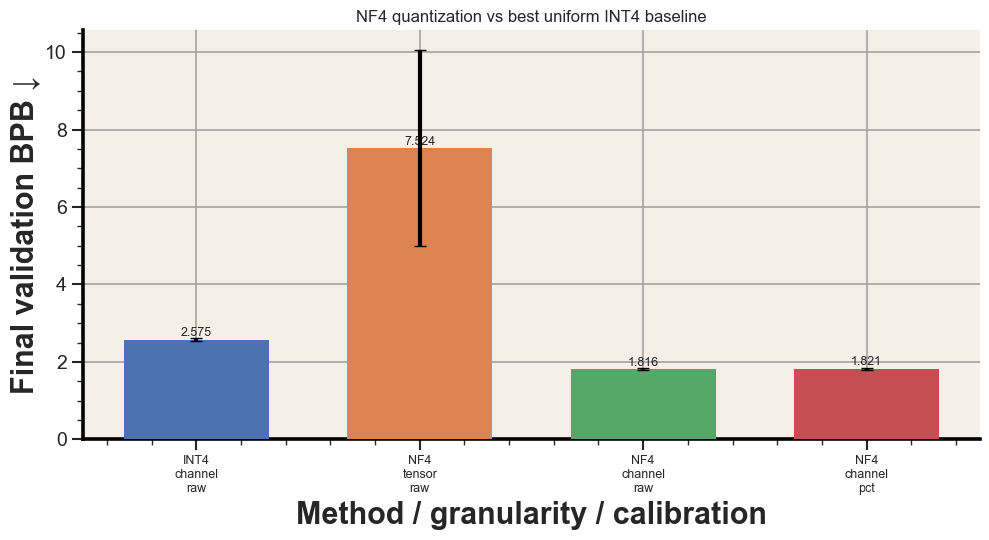

In [ ]:
plot_df = agg.copy()
plot_df["short_label"] = (
    plot_df["method"].map({"uniform_int4": "INT4", "nf4": "NF4"}) + "\n" +
    plot_df["granularity"].map({"per_tensor": "tensor", "per_channel": "channel"}) + "\n" +
    plot_df["calibration"].map({"uncalibrated": "raw", "percentile": "pct"})
)

fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(plot_df))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(plot_df))]

ax.bar(
    x,
    plot_df["final_val_bpb_mean"],
    yerr=plot_df["final_val_bpb_std"],
    capsize=4,
    color=colors,
    width=0.65,
    zorder=3,
)
for i, val in enumerate(plot_df["final_val_bpb_mean"]):
    ax.text(i, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["short_label"], fontsize=9)
ax.set_ylabel("Final validation BPB ↓")
ax.set_xlabel("Method / granularity / calibration")
ax.set_title("NF4 quantization vs best uniform INT4 baseline")
plt.tight_layout()
plt.savefig(OUT_DIR / "nf4_final_bpb_by_config.png", bbox_inches="tight")
plt.show()

## Plot: compressed file size by configuration

This checks whether NF4 packing gives a meaningful artifact-size benefit compared with the previous INT4 path.


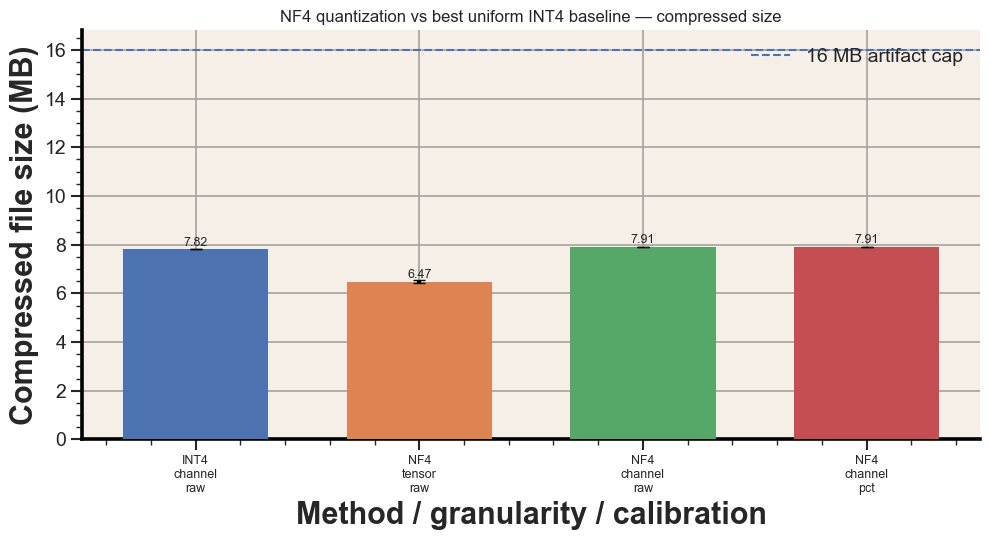

In [ ]:
if plot_df["quant_file_MB_mean"].isna().all():
    print("Skipping size plot: quant_file_MB not found in summaries.")
else:
    fig, ax = plt.subplots(figsize=(10, 5.5))
    x = np.arange(len(plot_df))
    colors = [PALETTE[i % len(PALETTE)] for i in range(len(plot_df))]

    ax.bar(
        x,
        plot_df["quant_file_MB_mean"],
        yerr=plot_df["quant_file_MB_std"],
        capsize=4,
        color=colors,
        width=0.65,
        zorder=3,
    )
    for i, val in enumerate(plot_df["quant_file_MB_mean"]):
        if pd.notna(val):
            ax.text(i, val + 0.02, f"{val:.2f}", ha="center", va="bottom", fontsize=9)

    ax.axhline(16.0, linestyle="--", linewidth=1.5, label="16 MB artifact cap")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["short_label"], fontsize=9)
    ax.set_ylabel("Compressed file size (MB)")
    ax.set_xlabel("Method / granularity / calibration")
    ax.set_title("NF4 quantization vs best uniform INT4 baseline — compressed size")
    ax.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / "nf4_compressed_size_by_config.png", bbox_inches="tight")
    plt.show()

## Pairwise NF4 effects

These tables compute paired differences inside NF4.

Examples:

- `per_channel - per_tensor`: negative means per-channel NF4 is better.
- `percentile - uncalibrated`: negative means percentile clipping is better.


In [ ]:
def paired_delta(data, index_cols, factor_col, a, b, metric="final_val_bpb_mean"):
    piv = data.pivot_table(index=index_cols, columns=factor_col, values=metric)
    if a in piv.columns and b in piv.columns:
        piv[f"{b} - {a}"] = piv[b] - piv[a]
    return piv.reset_index()

print("NF4 per-channel vs per-tensor: final_val_bpb_mean")
# Only uncalibrated exists for both per-tensor and per-channel in the recommended sweep.
delta_gran = paired_delta(
    nf4_only[nf4_only["calibration"] == "uncalibrated"],
    ["calibration"],
    "granularity",
    "per_tensor",
    "per_channel",
)
display(delta_gran)

print("\nNF4 percentile vs uncalibrated for per-channel: final_val_bpb_mean")
delta_cal = paired_delta(
    nf4_only[nf4_only["granularity"] == "per_channel"],
    ["granularity"],
    "calibration",
    "uncalibrated",
    "percentile",
)
display(delta_cal)

# Save deltas.
delta_gran.to_csv(OUT_DIR / "nf4_delta_per_channel_minus_per_tensor.csv", index=False)
delta_cal.to_csv(OUT_DIR / "nf4_delta_percentile_minus_uncalibrated.csv", index=False)

NF4 per-channel vs per-tensor: final_val_bpb_mean


granularity,calibration,per_channel,per_tensor,per_channel - per_tensor
0,uncalibrated,1.816285,7.523751,-5.707466



NF4 percentile vs uncalibrated for per-channel: final_val_bpb_mean


calibration,granularity,percentile,uncalibrated,percentile - uncalibrated
0,per_channel,1.821069,1.816285,0.004784


## Report-ready table

In [ ]:
report = agg[[
    "method", "bits", "granularity", "symmetry", "calibration", "n_seeds",
    "final_val_bpb_mean", "final_val_bpb_std",
    "delta_bpb_mean", "quant_file_MB_mean",
]].copy()

report["method"] = report["method"].map(DISPLAY_LABELS)
report["granularity"] = report["granularity"].map(DISPLAY_LABELS)
report["calibration"] = report["calibration"].map(DISPLAY_LABELS)

report_display = report.copy()
report_display["final_val_bpb"] = report_display.apply(
    lambda r: f"{r['final_val_bpb_mean']:.4f} ± {r['final_val_bpb_std']:.4f}" if pd.notna(r["final_val_bpb_std"]) else f"{r['final_val_bpb_mean']:.4f}",
    axis=1,
)
report_display["delta_bpb"] = report_display["delta_bpb_mean"].map(lambda x: f"{x:+.4f}" if pd.notna(x) else "—")
report_display["size_MB"] = report_display["quant_file_MB_mean"].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")

report_display = report_display[[
    "method", "bits", "granularity", "symmetry", "calibration", "n_seeds",
    "final_val_bpb", "delta_bpb", "size_MB",
]]

report_display.to_csv(OUT_DIR / "report_ready_nf4_table.csv", index=False)
report_display.to_markdown(OUT_DIR / "report_ready_nf4_table.md", index=False)
report_display

,method,bits,granularity,symmetry,calibration,n_seeds,final_val_bpb,delta_bpb,size_MB
0,Uniform INT4,4,per-channel,symmetric,uncalibrated,3,2.5749 ± 0.0328,+1.2683,7.82
1,NF4,4,per-tensor,codebook,uncalibrated,3,7.5238 ± 2.5315,+6.2175,6.47
2,NF4,4,per-channel,codebook,uncalibrated,3,1.8163 ± 0.0222,+0.5100,7.91
3,NF4,4,per-channel,codebook,percentile-clipped,3,1.8211 ± 0.0208,+0.5148,7.91


## NF4 Ablation Results

Best overall configuration: **NF4, per-channel, uncalibrated**, with final_val_bpb = **1.816285 ± 0.022225**.

Worst overall configuration: **NF4, per-tensor, uncalibrated**, with final_val_bpb = **7.523751 ± 2.531470**.

Relative to the best uniform INT4 baseline (2.574858 BPB), the best NF4 configuration improved over it by **-0.758573 BPB**.